# Introduction and Motivation: From QUBO to MaxCut

This notebook frames the problem class our project tackles. The story has three steps.

**1. Real-world combinatorial optimisation is hard.** Portfolio selection, job scheduling, facility location, network partitioning — all are binary decision problems with pairwise interactions, all NP-hard. Classical heuristics (Goemans–Williamson, simulated annealing, greedy) work but have known limits.

**2. They share a unifying language: QUBO.**

$$\min_{x\in\{0,1\}^n}\; x^T Q x + c^T x$$

QUBO (Quadratic Unconstrained Binary Optimisation) is the standard form for binary quadratic problems. Lucas (2014) gives explicit QUBO formulations for 25+ NP-hard problems, including every application in this notebook.

**3. QUBO has an Ising-spin form, which is the natural domain of quantum optimisation.** The substitution $x_i = (1-s_i)/2$ with $s_i \in \{-1,+1\}$ converts QUBO into a classical Ising Hamiltonian — the same object quantum spin systems are built around. This makes QUBO a natural target for quantum approaches such as quantum annealing and variational gate-based methods.

### Why MaxCut, then?

MaxCut is the **simplest QUBO** — pure pairwise interactions with no single-spin field ($h_i = 0$). Three reasons it is our canonical case:

1. **Cleanest formulation.** Only pairwise couplings $J_{ij}$ to specify; no linear bias.
2. **Standard benchmark.** Cross-paper comparability with the broader optimisation literature.
3. **Universality (Barahona 1982).** Every QUBO on $n$ variables is equivalent to MaxCut *on a signed-weighted graph* with $n+1$ vertices via a single ancilla. So MaxCut is a canonical entry point into the QUBO landscape; general QUBO adds fields and signed couplings on top.

In practice no reduction is performed; the algorithms in NB 01–07 use the Ising form directly. The reduction is the theoretical statement that **MaxCut is the natural starting case**, not that everything else is automatically free.

### What this notebook does

- §1: the common QUBO skeleton behind the four applications
- §2–§5: portfolio, scheduling, facility location, network partitioning — each as QUBO
- §6: QUBO ↔ MaxCut, why this class suits quantum methods, what makes MaxCut canonical

The actual quantum machinery — Pauli-$Z$ encoding, the QAOA ansatz, gate-level circuits — begins in NB 01. This notebook stops at the QUBO/Ising level.

See [README.md](README.md) for the full chapter walkthrough.

---
## 1. The Common QUBO Skeleton

The four applications below — portfolio, scheduling, facility location, network — share an identical mathematical structure:

- A set of **objects** (assets, jobs, sites, network nodes)
- **Pairwise relationships** between them (correlation, conflict, overlap, traffic)
- A binary **yes/no decision** for each object (buy/sell, slot A/B, open/close, zone left/right)

Mathematically, this is **QUBO**:

$$\min_{x\in\{0,1\}^n}\; x^T Q x + c^T x$$

with $Q$ encoding pairwise interactions and $c$ encoding individual costs. After substituting $x_i = (1 - s_i)/2$ with $s_i \in \{-1,+1\}$, the same problem becomes a classical *Ising model*

$$H = \sum_{i<j} J_{ij}\,s_i s_j + \sum_i h_i\,s_i + \mathrm{const}.$$

The mapping from each application to its $(Q, c)$ pair is what differs:

| Application | Variable $x_i$ | Pairwise $Q_{ij}$ | Linear $c_i$ |
|---|---|---|---|
| Portfolio selection | buy asset $i$? | covariance $\Sigma_{ij}$ | $-\mu_i$ + budget penalty |
| Job scheduling | slot A vs B for job $i$? | conflict $c_{ij}$ | (zero) |
| Facility location | open site $i$? | overlap $o_{ij}$ | $-v_i$ (value) |
| Network partitioning | zone of node $i$? | traffic $w_{ij}$ | (zero) |

In every case the input is a graph (vertices = objects, edge weights from $Q_{ij}$) plus optional per-vertex weights ($c_i$). Sections 2–5 work through these one by one. Section 6 returns to the unifying QUBO/Ising picture and explains why this class is amenable to quantum optimisation.

---
## 2. Portfolio Selection and Diversification

### 2.1 Markowitz Binary Selection (the standard QUBO)

An investor has $n$ candidate assets. Each asset $i$ has expected return $\mu_i$ and the assets have a covariance matrix $\Sigma$ (with $\Sigma_{ij} = \mathrm{Cov}(r_i, r_j)$). The decision is which $K$ assets to include, encoded as $x \in \{0,1\}^n$.

The standard formulation (Markowitz, binary version) is:

$$\min_{x\in\{0,1\}^n}\; x^T \Sigma x \;-\; q\,\mu^T x \quad \text{s.t.} \quad \sum_i x_i = K$$

- Quadratic $x^T \Sigma x$: portfolio variance (risk)
- Linear $-q\,\mu^T x$: expected return (with risk-aversion $q \ge 0$)
- Budget $\sum_i x_i = K$ becomes a penalty $\lambda(\sum_i x_i - K)^2$ inside the objective

This is a **QUBO with both linear and quadratic terms** — exactly the form §1 anticipated.

### 2.2 A Pure-MaxCut Framing: Risk-Only Partitioning

A different, related problem drops the return term and the budget and instead asks for the best **two-group partition** of the assets. With $s_i \in \{-1,+1\}$ assigning asset $i$ to one of two baskets:

$$\max_{s} \sum_{i<j}|\rho_{ij}|\;\frac{1 - s_i s_j}{2}$$

i.e. weighted MaxCut on the correlation graph (edge weight $|\rho_{ij}|$). This is *pure quadratic* — no linear field — so it is a clean MaxCut instance.

**Two finance interpretations of this partition:**

- **Within-basket diversification.** Maximising the cut places highly-correlated pairs in *different* baskets, so each basket is internally low-correlation. Either basket is a diversified portfolio. This is the 2-cluster version of *Hierarchical Risk Parity* (López de Prado 2016).
- **Long-short hedging.** Long one basket, short the other. Cross-basket correlation is maximised, so common factors cancel in the long-short and the residual is idiosyncratic — pairs trading generalised to baskets.

**Honest caveat.** §2.1 and §2.2 are *different optimisation problems on the same data* $\Sigma$. §2.1 is the canonical Markowitz selection problem (QUBO with linear field). §2.2 is a 2-clustering / hedging heuristic that happens to be pure MaxCut. Both are useful; both fit the QUBO/Ising framework discussed in §6.

### 2.3 Visualising Sector Structure

We construct synthetic 8-asset returns with sector structure (Tech, Finance, Energy) plus a small market factor. The correlation matrix shows clear blocks along sectors — intra-sector pairs have $|\rho| \approx 0.87$, inter-sector pairs only $\sim 0.3$. Thresholding at $|\rho_{ij}| > 0.5$ produces an unweighted graph dominated by intra-sector edges. The MaxCut on this graph **splits each sector across the two baskets**: intra-sector pairs are highly correlated, so cutting them is rewarded. The result is two baskets each containing a mix of sectors, with low *within-basket* correlation — which is exactly the diversification objective of §2.2.

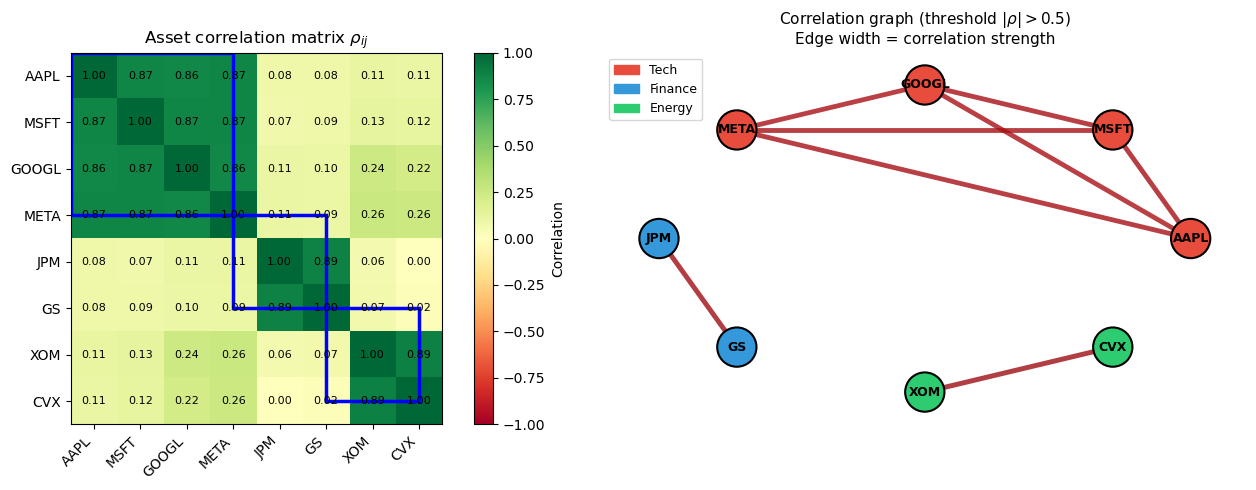

Assets: 8, Edges (|rho|>0.5): 8
Max intra-sector corr: Tech=0.872, Finance=0.886, Energy=0.893


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

rng = np.random.default_rng(42)
T = 500   # trading days
n_assets = 8
asset_names = ['AAPL','MSFT','GOOGL','META','JPM','GS','XOM','CVX']
sectors     = ['Tech','Tech','Tech','Tech','Finance','Finance','Energy','Energy']

# ── Synthetic returns with sector structure ───────────────────────
# Each sector has a common factor + idiosyncratic noise
tech_factor    = rng.normal(0, 1, T)
finance_factor = rng.normal(0, 1, T)
energy_factor  = rng.normal(0, 1, T)
market_factor  = rng.normal(0, 0.3, T)  # small common factor

loadings = {
    'AAPL':  (0.8, 0.0, 0.0), 'MSFT':  (0.8, 0.0, 0.0),
    'GOOGL': (0.7, 0.0, 0.1), 'META':  (0.7, 0.0, 0.1),
    'JPM':   (0.0, 0.8, 0.0), 'GS':    (0.0, 0.8, 0.0),
    'XOM':   (0.0, 0.0, 0.8), 'CVX':   (0.0, 0.0, 0.8),
}

returns = np.zeros((n_assets, T))
factors = np.array([tech_factor, finance_factor, energy_factor])
for k, name in enumerate(asset_names):
    load = np.array(loadings[name])
    returns[k] = load @ factors + market_factor + 0.3*rng.normal(0,1,T)

# ── Correlation matrix ────────────────────────────────────────────
corr = np.corrcoef(returns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[0], label='Correlation')
axes[0].set_xticks(range(n_assets)); axes[0].set_yticks(range(n_assets))
axes[0].set_xticklabels(asset_names, rotation=45, ha='right')
axes[0].set_yticklabels(asset_names)
for i in range(n_assets):
    for j in range(n_assets):
        axes[0].text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                     fontsize=8, color='black')
axes[0].set_title('Asset correlation matrix $\\rho_{ij}$', fontsize=12)

# Sector boxes
for (r0,r1,label) in [(0,3.5,'Tech'),(3.5,5.5,'Finance'),(5.5,7.5,'Energy')]:
    axes[0].add_patch(plt.Rectangle((r0-0.5,r0-0.5),r1-r0,r1-r0,
                     fill=False, edgecolor='blue', lw=2.5))

# Graph: threshold at |rho| > 0.5
tau = 0.5
G_port = nx.Graph()
G_port.add_nodes_from(range(n_assets))
for i in range(n_assets):
    for j in range(i+1, n_assets):
        if abs(corr[i,j]) > tau:
            G_port.add_edge(i, j, weight=abs(corr[i,j]))

pos = nx.circular_layout(G_port)
sector_colors = {'Tech':'#E74C3C','Finance':'#3498DB','Energy':'#2ECC71'}
node_colors   = [sector_colors[sectors[k]] for k in range(n_assets)]
edge_weights  = [G_port[u][v]['weight'] for u,v in G_port.edges()]

nx.draw_networkx_nodes(G_port, pos, ax=axes[1], node_color=node_colors,
                       node_size=800, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_port, pos, ax=axes[1],
                        labels={k:asset_names[k] for k in range(n_assets)},
                        font_size=9, font_weight='bold')
nx.draw_networkx_edges(G_port, pos, ax=axes[1],
                       width=[w*4 for w in edge_weights],
                       edge_color=edge_weights, edge_cmap=plt.cm.Reds,
                       alpha=0.8, edge_vmin=0, edge_vmax=1)
axes[1].set_title(f'Correlation graph (threshold $|\\rho|>{tau}$)\n'
                  'Edge width = correlation strength', fontsize=11)
axes[1].axis('off')

from matplotlib.patches import Patch
legend = [Patch(color=c, label=s) for s,c in sector_colors.items()]
axes[1].legend(handles=legend, loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

print(f'Assets: {n_assets}, Edges (|rho|>{tau}): {G_port.number_of_edges()}')
print(f'Max intra-sector corr: '
      f'Tech={max(corr[i,j] for i in range(4) for j in range(i+1,4)):.3f}, '
      f'Finance={corr[4,5]:.3f}, Energy={corr[6,7]:.3f}')

### 2.4 MaxCut Solution Achieves Diversification by Splitting Sectors

We solve the §2.2 MaxCut on the thresholded correlation graph using Goemans–Williamson SDP rounding. Because the graph's edges live almost entirely *inside* each sector (intra-sector $|\rho| \approx 0.87$ exceeds the threshold; inter-sector pairs do not), MaxCut is rewarded for **separating sector-mates into different baskets**. Each resulting basket contains a mix of Tech, Finance, and Energy assets — the partition runs *across* sector boundaries, not along them. The within-basket mean correlation drops well below the intra-sector $0.87$, recovering the diversification objective from §2.2.

In [ ]:
import cvxpy as cp

# ── Weighted MaxCut via GW SDP ────────────────────────────────────
edges_port = list(G_port.edges())
weights_port = [G_port[u][v]['weight'] for u,v in edges_port]

def weighted_cut_val(assignment, edges, weights):
    return sum(w for (i,j),w in zip(edges,weights) if assignment[i]!=assignment[j])

def weighted_maxcut_sdp(n, edges, weights, n_rounds=3000):
    X = cp.Variable((n,n), symmetric=True)
    obj = cp.Maximize(sum(0.5*w*(1-X[i,j]) for (i,j),w in zip(edges,weights)))
    prob = cp.Problem(obj, [X >> 0] + [X[i,i]==1 for i in range(n)])
    prob.solve(solver=cp.SCS, verbose=False)
    eigvals, eigvecs = np.linalg.eigh(X.value)
    eigvals = np.maximum(eigvals, 1e-6)
    V = eigvecs @ np.diag(np.sqrt(eigvals))
    best_cut = -1; best_assign = None
    for _ in range(n_rounds):
        r = rng.standard_normal(n); r /= np.linalg.norm(r)
        assign = (V @ r >= 0).astype(int)
        cv = weighted_cut_val(assign, edges, weights)
        if cv > best_cut:
            best_cut = cv; best_assign = assign.copy()
    return best_assign, best_cut

assign_port, cut_port = weighted_maxcut_sdp(n_assets, edges_port, weights_port)

# ── Visualise the partition ───────────────────────────────────────
group0 = [i for i in range(n_assets) if assign_port[i]==0]
group1 = [i for i in range(n_assets) if assign_port[i]==1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph with partition
node_colors_cut = ['#E74C3C' if assign_port[k]==0 else '#3498DB' for k in range(n_assets)]
cut_edges    = [(i,j) for i,j in edges_port if assign_port[i]!=assign_port[j]]
noncut_edges = [(i,j) for i,j in edges_port if assign_port[i]==assign_port[j]]

nx.draw_networkx_nodes(G_port, pos, ax=axes[0], node_color=node_colors_cut,
                       node_size=900, edgecolors='black', linewidths=2)
nx.draw_networkx_labels(G_port, pos, ax=axes[0],
                        labels={k:asset_names[k] for k in range(n_assets)},
                        font_size=9, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G_port, pos, ax=axes[0], edgelist=cut_edges,
                       edge_color='green', width=3.0, alpha=0.8,
                       style='solid', label='Cut (separated)')
nx.draw_networkx_edges(G_port, pos, ax=axes[0], edgelist=noncut_edges,
                       edge_color='red', width=2.0, alpha=0.5,
                       style='dashed', label='Not cut (same group)')
axes[0].set_title(f'MaxCut partition (GW SDP)\n'
                  f'Weighted cut = {cut_port:.3f}', fontsize=11)
axes[0].axis('off')
axes[0].legend(loc='upper left', fontsize=9)

# Within-group correlation heatmaps
ax2 = axes[1]
for group, color, label, xpos in [
    (group0, '#E74C3C', 'Group S (red)', 0),
    (group1, '#3498DB', r'Group $\bar{S}$ (blue)', 1)
]:
    within_corrs = [corr[i,j] for i in group for j in group if i<j]
    between_corrs= [corr[i,j] for i in group for j in (
        group1 if group==group0 else group0)]
    ax2.bar(xpos*2, np.mean(np.abs(within_corrs)) if within_corrs else 0,
            color=color, width=0.6, label=f'{label}: within')
    ax2.bar(xpos*2+0.7, np.mean(np.abs(between_corrs)),
            color=color, alpha=0.4, width=0.6, label=f'{label}: between-group')

ax2.set_xticks([0.35, 2.35])
ax2.set_xticklabels(['Group S', r'Group $\bar{S}$'], fontsize=11)
ax2.set_ylabel('Mean |correlation|', fontsize=11)
ax2.set_title('Within-group vs between-group correlation\n'
              '(lower within = more diversified)', fontsize=10)
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Group S  (red):  {[asset_names[i] for i in group0]}')
print(f'Group Sbar(blue): {[asset_names[i] for i in group1]}')

# Check that MaxCut splits each sector across the two baskets
# (the actual claim of §2.4: high-correlation intra-sector pairs are separated)
sector_idx = [{0,1,2,3}, {4,5}, {6,7}]   # Tech, Finance, Energy
sector_names = ['Tech', 'Finance', 'Energy']
sectors_split = all(
    len(set(group).intersection(s)) > 0
    for s in sector_idx
    for group in [group0, group1]
)
print(f'Each sector split across baskets: {"Yes" if sectors_split else "Partial"}')
for s, name in zip(sector_idx, sector_names):
    in_S    = sorted(set(group0).intersection(s))
    in_Sbar = sorted(set(group1).intersection(s))
    print(f'  {name:8s}: S={[asset_names[i] for i in in_S]}, '
          f'Sbar={[asset_names[i] for i in in_Sbar]}')

---
## 3. Job Scheduling

### 3.1 The Problem

We have $n$ jobs to schedule into **two time slots** (A and B). Some pairs of jobs **conflict** — they require the same resource and cannot run simultaneously. Goal: assign jobs to slots to minimise the conflict cost incurred *within* each slot.

Let $c_{ij}\geq 0$ be the conflict penalty if jobs $i$ and $j$ run in the same slot, and let $z_i \in \{0,1\}$ denote the slot assignment. The total conflict cost is

$$\text{Conflict}(z) = \sum_{(i,j)\in E} c_{ij}\,\mathbf{1}[z_i = z_j].$$

### 3.2 QUBO and Ising Forms

Expanding $\mathbf{1}[z_i = z_j] = 1 - (z_i - z_j)^2 = 1 - z_i - z_j + 2 z_i z_j$ (using $z_i^2 = z_i$ for $z_i \in \{0,1\}$) gives a QUBO with **both pairwise and linear terms**:

$$\sum_{(i,j)\in E} c_{ij}\,\mathbf{1}[z_i = z_j] \;=\; \underbrace{\sum_{(i,j)\in E} c_{ij}}_{\text{const}} \;-\; \sum_i \deg_c(i)\,z_i \;+\; 2\sum_{(i,j)\in E} c_{ij}\,z_i z_j,$$

where $\deg_c(i) = \sum_{j:(i,j)\in E} c_{ij}$ is the conflict-degree of job $i$. The linear $-\deg_c(i)\,z_i$ term *does not vanish* — it is degree-weighted on each vertex.

In **spin variables** $s_i \in \{-1,+1\}$ with $z_i = (1-s_i)/2$, the cleaner identity $\mathbf{1}[z_i = z_j] = (1 + s_i s_j)/2$ collapses constant and linear pieces together, giving a **pure quadratic** Ising form:

$$\sum_{(i,j)\in E} c_{ij}\,\mathbf{1}[z_i = z_j] \;=\; \tfrac{1}{2}\sum_{(i,j)\in E} c_{ij} \;+\; \tfrac{1}{2}\sum_{(i,j)\in E} c_{ij}\,s_i s_j.$$

So job-scheduling-on-conflict-graph has a pure-quadratic Ising form ($h_i = 0$).

### 3.3 MaxCut as the Special Case

Because the Ising form is pure quadratic, the equivalence

$$\min\,\text{Conflict}(z) \;\;\Longleftrightarrow\;\; \max\, \sum_{(i,j)\in E} c_{ij}\,\mathbf{1}[z_i \neq z_j] \;\;=\;\; \boxed{\max\, C_w(z)\;\text{(weighted MaxCut)}}$$

is exact and ancilla-free. Vertex $i$ = job $i$, edge weight $w_{ij} = c_{ij}$. MaxCut separates conflicting jobs into different slots.

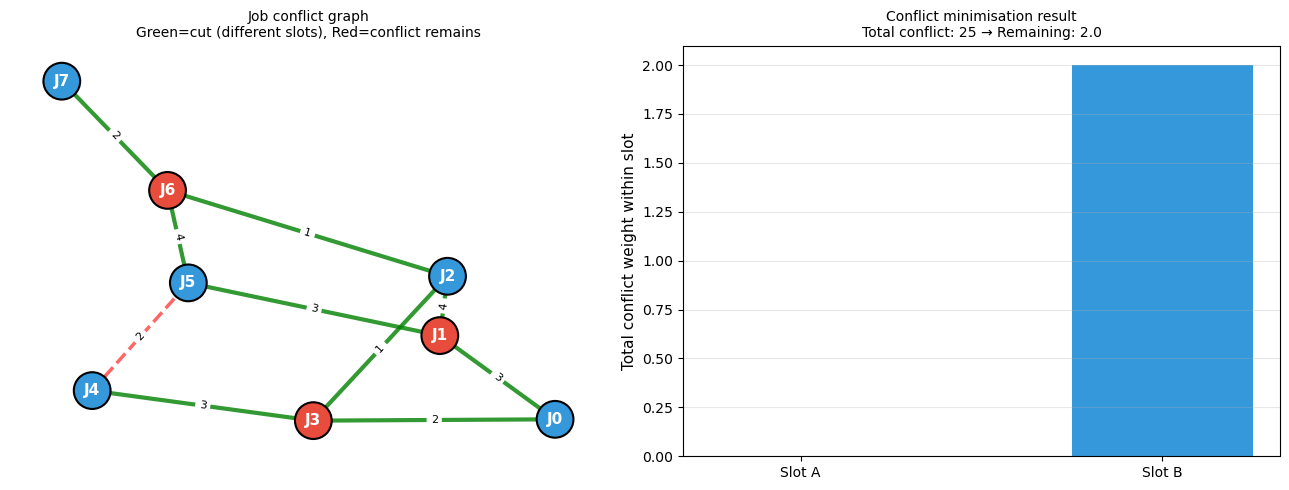

Slot A: ['J1', 'J3', 'J6']
Slot B: ['J0', 'J2', 'J4', 'J5', 'J7']
Total conflict weight: 25
Remaining after MaxCut: 2.0  (8.0%)


In [3]:
# Job scheduling: synthetic example
n_jobs = 8
job_names = [f'J{k}' for k in range(n_jobs)]

# Conflict graph: some job pairs share resources
conflicts = [(0,1,3),(0,3,2),(1,2,4),(2,3,1),(3,4,3),(4,5,2),
             (5,6,4),(6,7,2),(1,5,3),(2,6,1)]
# (i, j, conflict_weight)

G_sched = nx.Graph()
G_sched.add_nodes_from(range(n_jobs))
for i,j,w in conflicts:
    G_sched.add_edge(i,j,weight=w)

# GW to find good assignment
edges_s = list(G_sched.edges())
wts_s   = [G_sched[u][v]['weight'] for u,v in edges_s]
assign_s, cut_s = weighted_maxcut_sdp(n_jobs, edges_s, wts_s)

total_conflict = sum(w for i,j,w in conflicts)
remaining = total_conflict - cut_s

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pos_s = nx.spring_layout(G_sched, seed=7)
node_cols_s = ['#E74C3C' if assign_s[k]==0 else '#3498DB' for k in range(n_jobs)]
cut_e_s = [(i,j) for i,j in edges_s if assign_s[i]!=assign_s[j]]
same_e_s= [(i,j) for i,j in edges_s if assign_s[i]==assign_s[j]]
edge_w_s= [G_sched[u][v]['weight'] for u,v in edges_s]

nx.draw_networkx_nodes(G_sched, pos_s, ax=axes[0], node_color=node_cols_s,
                       node_size=700, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_sched, pos_s, ax=axes[0],
                        labels={k:job_names[k] for k in range(n_jobs)},
                        font_size=11, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G_sched, pos_s, ax=axes[0], edgelist=cut_e_s,
                       edge_color='green', width=3, alpha=0.8)
nx.draw_networkx_edges(G_sched, pos_s, ax=axes[0], edgelist=same_e_s,
                       edge_color='red', width=2.5, alpha=0.6, style='dashed')
edge_labels_s = {(i,j):G_sched[i][j]['weight'] for i,j in edges_s}
nx.draw_networkx_edge_labels(G_sched, pos_s, ax=axes[0], edge_labels=edge_labels_s, font_size=8)
axes[0].set_title('Job conflict graph\nGreen=cut (different slots), Red=conflict remains', fontsize=10)
axes[0].axis('off')

# Bar: slot A vs slot B
slotA = [job_names[k] for k in range(n_jobs) if assign_s[k]==0]
slotB = [job_names[k] for k in range(n_jobs) if assign_s[k]==1]
axes[1].bar(['Slot A','Slot B'],
           [sum(w for i,j,w in conflicts if assign_s[i]==0 and assign_s[j]==0),
            sum(w for i,j,w in conflicts if assign_s[i]==1 and assign_s[j]==1)],
           color=['#E74C3C','#3498DB'], width=0.5)
axes[1].set_ylabel('Total conflict weight within slot', fontsize=11)
axes[1].set_title(f'Conflict minimisation result\n'
                  f'Total conflict: {total_conflict} → Remaining: {remaining:.1f}', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Slot A: {slotA}')
print(f'Slot B: {slotB}')
print(f'Total conflict weight: {total_conflict}')
print(f'Remaining after MaxCut: {remaining:.1f}  ({remaining/total_conflict*100:.1f}%)')

---
## 4. Facility Location

### 4.1 The Problem

We have $n$ candidate sites for facilities (warehouses, antennas, charging stations). Each site $i$ has a coverage value $v_i$ if opened. Pairs of geographically close sites $(i,j)$ have an **overlap penalty** $o_{ij} \geq 0$: opening both wastes service capacity. Decide which sites to open, $x_i \in \{0,1\}$, to maximise net benefit.

### 4.2 QUBO Formulation

The natural objective is "value gained minus overlap incurred":

$$\max_{x\in\{0,1\}^n}\;\sum_i v_i\,x_i\;-\;\sum_{(i,j)\in E} o_{ij}\,x_i x_j$$

which (after sign flip to minimise) is a QUBO with

- pairwise term $Q_{ij} = o_{ij}$ (overlap penalty),
- linear term $c_i = -v_i$ (value of opening site $i$).

This QUBO has a **non-trivial linear field** — not pure MaxCut on the natural overlap graph. By §6.4 it is equivalent to MaxCut on $n+1$ vertices via an ancilla connecting to every site.

### 4.3 Classical Ising Form

Substituting $x_i = (1 - s_i)/2$ with $s_i \in \{-1,+1\}$ in both terms and collecting (using $\sum_{(i,j)\in E} o_{ij}(s_i + s_j) = \sum_i D_i\,s_i$ where $D_i = \sum_{j:(i,j)\in E} o_{ij}$ is the overlap-degree at site $i$) gives the Ising Hamiltonian

$$H \;=\; \tfrac{1}{4}\sum_{(i,j)\in E} o_{ij}\,s_i s_j \;+\; \sum_i \!\left(\tfrac{v_i}{2} - \tfrac{D_i}{4}\right)\!s_i \;+\; \mathrm{const}.$$

Two things to notice:

- **The coupling carries a factor of $1/4$** (not $o_{ij}$ itself) — it comes from $x_ix_j = (1-s_i)(1-s_j)/4$.
- **The single-spin field is *not* simply $-v_i/2$.** Expanding $x_ix_j$ also contributes $-D_i/4$ to each $s_i$, so the field absorbs neighbour-overlap. The combined coefficient $h_i = v_i/2 - D_i/4$ favours opening a high-value site and discourages opening sites with large overlap-degree, exactly as the QUBO objective demands.

This is a classical Ising Hamiltonian; how a quantum algorithm (QAOA) targets such Hamiltonians is the subject of NB 01.

---
## 5. Network Design and Graph Partitioning

### 5.1 Parallel Computing: Load Balancing

In parallel computing, a workload graph has tasks as vertices and communication requirements as weighted edges, with $w_{ij}$ = data exchanged between tasks $i$ and $j$. Assigning each task to one of two processors ($z_i \in \{0,1\}$), tasks on the **same processor** communicate through fast local memory (cheap), tasks on **different processors** through a network bus (expensive). The cost is

$$\text{Communication}(z) = \sum_{(i,j)\in E} w_{ij}\,\mathbf{1}[z_i \neq z_j].$$

This looks like MaxCut with the sign flipped, but **plain MinCut is trivial**: putting every task on one processor cuts no edges and the cost is zero. The non-trivial problem is **balanced minimum cut** — *minimum bisection* — with the constraint $|S| = |\bar S| = n/2$.

### 5.2 Telecom Network Design

A telecom company partitions $n$ users into two zones. Within-zone traffic is handled locally; between-zone traffic crosses an expensive backbone. Minimum backbone cost is again minimum bisection on the user-traffic graph.

### 5.3 MinCut, MaxCut, and the Complement-Graph Relation

> **Same QUBO family.** Both MaxCut and MinCut are special cases of QUBO with $Q_{ij} = \pm w_{ij}$, differing only in the sign of the Ising couplings.
>
> **Balance is essential.** Plain MinCut is trivial (cut value $0$ when one side is empty). The meaningful problem is *minimum bisection*. Subject to the balance constraint $|S| = |\bar S| = n/2$, the cut on $G$ plus the cut on the complement graph $\bar G$ equals a constant, so **a minimum bisection of $G$ is a maximum bisection of $\bar G$** — and vice versa. Without the bisection constraint this complement-graph identity does not hold.
>
> **Encoding the balance constraint.** It is enforced via a soft penalty $\lambda(\sum_i s_i)^2$, which is itself an Ising term and folds into the cost Hamiltonian alongside the original couplings. The QUBO/Ising structure is preserved.

---
## 6. QUBO ↔ MaxCut, and Why This Class Suits Quantum Methods

§2–§5 covered four applications. They look different on the surface — finance, scheduling, logistics, networks — but share a single mathematical form. This section pins that form down and motivates why MaxCut is the canonical case to study. The actual quantum algorithm (QAOA) is developed from scratch in NB 01.

### 6.1 What is QUBO?

**Quadratic Unconstrained Binary Optimisation:**

$$\min_{x\in\{0,1\}^n}\; x^T Q x + c^T x.$$

- $x_i \in \{0,1\}$: binary decision (buy/sell, slot A/B, open/close, zone left/right)
- $Q \in \mathbb{R}^{n\times n}$: pairwise interactions
- $c \in \mathbb{R}^n$: linear bias
- "Unconstrained" because hard constraints are folded into the objective via penalty terms (e.g. $\lambda(\sum x_i - K)^2$ for a budget)

QUBO is the standard form for a huge class of NP-hard problems. Lucas (2014) gives explicit QUBO formulations for **25+ NP-hard problems**, including all four applications above plus graph colouring, vertex cover, set cover, knapsack, TSP, and more.

### 6.2 Why QUBO Is a Natural Quantum Target

Substituting $x_i = (1 - s_i)/2$ with $s_i \in \{-1,+1\}$, the QUBO becomes a classical **Ising Hamiltonian**

$$H \;=\; \sum_{i<j} J_{ij}\,s_i s_j \;+\; \sum_i h_i\,s_i \;+\; \mathrm{const}.$$

Two reasons this matters for quantum optimisation:

- **Native to quantum spin systems.** The Ising form is exactly the kind of object quantum spin platforms are built around — quantum annealers (e.g. D-Wave) implement it as their core primitive, and gate-based devices encode it via Pauli operators with standard gate sets. Hard constraints fold into the same form via penalty terms. Real-hardware cost (depth, gate count) of course depends on connectivity and embedding.
- **Variational quantum algorithms target it directly.** QAOA, the algorithm we develop in NB 01–07, is built around exactly this class: it parameterises a quantum state to minimise the expectation of a chosen Ising Hamiltonian.

The actual quantum encoding ($s_i \to Z_i$), the QAOA ansatz, and the gate-level circuit are introduced in NB 01.

### 6.3 MaxCut as the Canonical Special Case

MaxCut is the QUBO with **no linear field** ($h_i = 0$):

$$H \;=\; \sum_{(i,j)\in E} w_{ij}\,\frac{1 - s_i s_j}{2}.$$

In the standard "unweighted MaxCut" benchmark we additionally have $w_{ij} \geq 0$. This is the simplest non-trivial Ising Hamiltonian — pure pairwise interactions, no single-spin term. Three consequences:

- **Simplest setup.** Only $J_{ij}$ to specify; no $h_i$.
- **Cleanest theory.** Classical approximation results (e.g. the Goemans–Williamson $0.8786$ bound) are stated for nonnegative-weight MaxCut, and theoretical analyses of quantum algorithms on this class follow the same pattern.
- **Standard benchmark.** Cross-paper comparable — both classical and quantum work uses MaxCut instances.

This is why our notebooks 01–07 take MaxCut as the running example.

### 6.4 Universality: QUBO ⟺ MaxCut on $n+1$ Vertices (with signed weights)

**Theorem (Barahona 1982).** Every QUBO on $n$ binary variables is equivalent to MaxCut on a *signed-weighted* graph with $n+1$ vertices, where the original couplings $J_{ij}$ become edge weights and the original fields $h_i$ become weights of edges from a new ancilla vertex $s_0$ to each $i$.

*Proof sketch.* In Ising form $H = \sum h_i s_i + \sum J_{ij} s_i s_j$, introduce an ancilla spin $s_0$ and use $s_0^2 = 1$ to rewrite $h_i s_i = h_i s_i s_0$. Now every term is quadratic — a MaxCut instance on the augmented graph (original couplings $J_{ij}$ plus a star of edges $h_i$ from $s_0$ to every other vertex). The ground-state $s_0$ direction is fixed by the global $\mathbb{Z}_2$ symmetry of MaxCut. ∎

**Caveat: signed weights, not unweighted MaxCut.** The reduction generally produces *signed* edge weights — couplings $J_{ij}$ retain their sign, and the ancilla edges carry weight $h_i$ which can be either sign. So this is "MaxCut on signed/weighted graphs", a strict generalisation of the unweighted-nonnegative MaxCut studied in classical approximation theory. **Classical guarantees like the Goemans–Williamson $0.8786$ bound assume nonnegative weights and do not transfer verbatim** to the reduced instance.

**What this buys us.** The reduction shows MaxCut is a *canonical entry point* into the QUBO/Ising landscape: methodology developed for MaxCut transfers in form to any Ising Hamiltonian (only fields and signed couplings are added). Quantitative results — approximation ratios, optimal parameter profiles, noise behaviour — must be re-evaluated for each new instance, especially when fields $h_i$ or signed couplings are present.

### 6.5 Why MaxCut Is the Right Starting Case

Pulling §6.1–§6.4 together, MaxCut is the natural starting case because it is

1. **The simplest QUBO** — pure pairwise, no field, minimal $H$.
2. **Universal in form** — by Barahona, every QUBO reduces to MaxCut on $n+1$ vertices, so MaxCut analysis is a canonical entry point into the entire Ising landscape.
3. **Physically meaningful** — MaxCut is exactly the antiferromagnetic-Ising ground-state problem. Frustrated Ising systems are precisely where classical heuristics struggle, and a problem class with that physics is a natural candidate for quantum methods.
4. **A standard benchmark** — both classical and quantum literature reports performance on MaxCut instances, so results are cross-comparable.

| Problem | $Q$ matrix | Linear $c_i$ |
|---|---|---|
| MaxCut | $Q_{ij}=-w_{ij}$, $Q_{ii}=\deg(i)$ | $0$ |
| Portfolio (Markowitz) | $\Sigma_{ij}$ on off-diagonal | $-\mu_i$ + budget penalty |
| Job scheduling | $Q_{ij}=c_{ij}$ (conflict) | $0$ |
| Facility location | $Q_{ij}=o_{ij}$ | $-v_i$ (value) |
| Min bisection | $Q_{ij}=+w_{ij}$ | $0$, plus $\lambda(\sum_i x_i - n/2)^2$ penalty |

The QUBO form is the same; only the entries of $Q$ and $c$ change with the application. NB 01 takes this Ising Hamiltonian and shows how QAOA encodes and optimises it.

In [ ]:
# ── Summary visualisation: problem taxonomy ──────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Draw hierarchy
boxes = [
    # (x, y, w, h, text, color)
    (0.35, 0.78, 0.30, 0.14, 'Combinatorial\nOptimisation\n(NP-hard)', '#2C3E50'),
    (0.35, 0.56, 0.30, 0.14, 'QUBO\n$\\min x^T Q x + c^T x$', '#8E44AD'),
    (0.35, 0.34, 0.30, 0.14, 'Classical Ising\n$H = \\sum J_{ij}s_i s_j + \\sum h_i s_i$', '#2980B9'),
    (0.35, 0.12, 0.30, 0.14, 'Quantum optimisation\n(QAOA: see NB 01)', '#27AE60'),
]
applications = [
    (0.00, 0.78, 0.22, 0.10, 'Portfolio\nDiversification', '#E74C3C'),
    (0.78, 0.78, 0.22, 0.10, 'Job\nScheduling', '#E67E22'),
    (0.00, 0.60, 0.22, 0.10, 'Facility\nLocation', '#16A085'),
    (0.78, 0.60, 0.22, 0.10, 'Network\nDesign', '#8E44AD'),
    (0.00, 0.42, 0.22, 0.10, 'Graph\nPartitioning', '#2980B9'),
    (0.78, 0.42, 0.22, 0.10, 'Resource\nAllocation', '#C0392B'),
]

for x,y,w,h,text,color in boxes:
    rect = plt.Rectangle((x,y), w, h, facecolor=color, edgecolor='white',
                         lw=2, transform=ax.transAxes, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', transform=ax.transAxes)

for x,y,w,h,text,color in applications:
    rect = plt.Rectangle((x,y), w, h, facecolor=color, edgecolor='white',
                         lw=1.5, transform=ax.transAxes, alpha=0.75)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold', transform=ax.transAxes)

# Arrows (main chain)
for y_start, y_end in [(0.78, 0.70), (0.56, 0.48), (0.34, 0.26)]:
    ax.annotate('', xy=(0.50, y_end), xytext=(0.50, y_start),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='white', lw=2.5))

# Arrows from applications to QUBO box
for x,y,w,h,_,_ in applications:
    ax.annotate('', xy=(0.35, 0.63), xytext=(x+w, y+h/2),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2, alpha=0.6))

ax.set_title('From real problems to QUBO/Ising: the unifying pipeline', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Key Takeaways

1. **QUBO is the unifying language.** Portfolio selection, job scheduling, facility location, and network partitioning are all QUBO problems — each specified by a $(Q, c)$ matrix pair. Lucas (2014) catalogues 25+ NP-hard problems in the same form.

2. **QUBO has a classical Ising form.** The substitution $x_i = (1-s_i)/2$ converts QUBO into $H = \sum J_{ij} s_i s_j + \sum h_i s_i + \mathrm{const}$. This is the form quantum spin platforms (annealers, gate-based devices) are built around — making QUBO a natural target for quantum optimisation. The actual quantum encoding and algorithm (QAOA) are introduced in NB 01.

3. **MaxCut is the simplest QUBO** ($h_i = 0$, pure pairwise). It admits the cleanest formulation, the cleanest classical theory, and serves as the standard cross-paper benchmark — which is why our entire project takes MaxCut as the running example.

4. **Universality (Barahona 1982).** Any QUBO on $n$ variables is equivalent to MaxCut *with signed weights* on $n+1$ vertices via a single ancilla. This is a *theoretical safety net*: focusing on MaxCut means losing no generality of *form*. The signed-weight caveat means classical approximation guarantees written for nonnegative-weight MaxCut do not transfer verbatim to arbitrary QUBO instances. In practice no reduction is performed — Ising Hamiltonians are used directly.

5. **One QUBO form, many applications.** The structure $\min x^T Q x + c^T x$ is fixed across every application; only the numerical entries of $Q$ and $c$ change.

6. **Classical baseline.** Goemans–Williamson SDP rounding is the **standard polynomial-time approximation baseline** for nonnegative-weight MaxCut, with guaranteed ratio $\geq 0.8786$ (and tight under the Unique Games Conjecture). Whether quantum methods can match or exceed this baseline on practical instances is an active question — empirically examined in NB 05.

---
## References

- Barahona, F. *On the computational complexity of Ising spin glass models.* J. Phys. A **15**, 3241 (1982).
- Glover, Kochenberger, Du. *Quantum Bridge Analytics I: QUBO formulations.* 4OR **17**, 335–371 (2019).
- Goemans, Williamson. *Improved approximation algorithms for maximum cut and satisfiability problems.* JACM **42**(6), 1115–1145 (1995).
- Karp, R. *Reducibility among combinatorial problems.* In *Complexity of Computer Computations*, Plenum (1972).
- Khot, S., Kindler, G., Mossel, E., O'Donnell, R. *Optimal inapproximability results for MAX-CUT and other 2-variable CSPs.* JACM **54**(3), 2007.
- López de Prado, M. *Building diversified portfolios that outperform out of sample.* Journal of Portfolio Management **42**(4), 59–69 (2016).
- Lucas, A. *Ising formulations of many NP problems.* Front. Phys. **2**, 5 (2014).